## Sigmoid-parameterized REINFORCE, CPU / joblib

In [1]:
import os
import pickle
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from Functions import (cost_per_sample, generate_legal_neighbors, barker, compute_A)

plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})


In [2]:
# Backup / output setup 
RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"run_{RUN_ID}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "checkpoint.pkl")

print(f"Output directory: {OUTPUT_DIR}")

def save_figure(fig, name):
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.svg"), bbox_inches="tight")

def save_checkpoint(state):
    tmp_path = CHECKPOINT_PATH + ".tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    os.replace(tmp_path, CHECKPOINT_PATH)


Output directory: run_20260720_151538


## Functions
`beta_of_t` is the sigmoid 

In [3]:
def beta_of_t(t, beta_min, beta_max, k, t0):
    """The sigmoid schedule. t can be a scalar or a numpy array.
    Returns (beta_t, sigma_t) -- sigma_t is reused by the gradient below."""
    sigma_t = 1.0 / (1.0 + np.exp(-k * (t - t0)))
    beta_t = beta_min + (beta_max - beta_min) * sigma_t
    return beta_t, sigma_t


def RL_trajectory_schedule_sigmoid(d0, Gamma, A, H, beta_min, beta_max, k, t0, num_time_steps):
    """One trajectory under the sigmoid schedule. At each step:
      1. compute beta_t from the 4 current parameters
      2. run the same Barker accept/reject as before
      3. compute d(logP_t)/d(beta_t)  -- identical formula to the block version
      4. chain rule: d(logP_t)/d(theta_i) = d(logP_t)/d(beta_t) * d(beta_t)/d(theta_i)
         for each of the 4 parameters, and accumulate into grad_theta
    Returns (d, E_current, grad_theta) -- grad_theta has shape (4,):
    [d/d(beta_min), d/d(beta_max), d/dk, d/dt0]"""
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_theta = np.zeros(4)

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        beta_t, sigma_t = beta_of_t(t, beta_min, beta_max, k, t0)
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            dlogP_dbeta = -deltaE / (1 + np.exp(-beta_t * deltaE))
            d, E_current = d_prime, E_prime
        else:
            dlogP_dbeta = deltaE / (1 + np.exp(beta_t * deltaE))

        # chain rule: d(beta_t)/d(theta) for each of the 4 named parameters
        dbeta_dbmin = 1 - sigma_t
        dbeta_dbmax = sigma_t
        dbeta_dk    = (beta_max - beta_min) * sigma_t * (1 - sigma_t) * (t - t0)
        dbeta_dt0   = -k * (beta_max - beta_min) * sigma_t * (1 - sigma_t)

        grad_theta[0] += dlogP_dbeta * dbeta_dbmin
        grad_theta[1] += dlogP_dbeta * dbeta_dbmax
        grad_theta[2] += dlogP_dbeta * dbeta_dk
        grad_theta[3] += dlogP_dbeta * dbeta_dt0

    return d, E_current, grad_theta


def run_experiment_sigmoid(d0, Gamma, A, H, beta_min, beta_max, k, t0, num_time_steps):
    _, E_final, grad_theta = RL_trajectory_schedule_sigmoid(
        d0, Gamma, A, H, beta_min, beta_max, k, t0, num_time_steps
    )
    return E_final, grad_theta


def grad_expectedcost_sigmoid(d0, Gamma, beta_min, beta_max, k, t0, num_time_steps,
                               num_independent_experiments, ema_baseline=None, ema_decay=0.9):
    """joblib-parallelized batch of trajectories, EMA-baselined REINFORCE gradient
    for the 4 sigmoid parameters. Returns (costs, grad_theta, ema_baseline)."""
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment_sigmoid)(d0, Gamma, A, H, beta_min, beta_max, k, t0, num_time_steps)
        for _ in range(num_independent_experiments)
    )

    costs = np.array([r[0] for r in results])
    grad_matrix = np.array([r[1] for r in results])  # shape (N_E, 4)

    batch_mean = costs.mean()
    if ema_baseline is None:
        ema_baseline = batch_mean
    else:
        ema_baseline = ema_decay * ema_baseline + (1 - ema_decay) * batch_mean

    advantage = costs - ema_baseline
    grad_theta = np.mean(advantage[:, None] * grad_matrix, axis=0)

    return costs, grad_theta, ema_baseline


def evaluate_sigmoid(d0, Gamma, beta_min, beta_max, k, t0, num_time_steps, num_eval_experiments):
    """Held-out evaluation: fresh trajectories, no gradient tracking."""
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment_sigmoid)(d0, Gamma, A, H, beta_min, beta_max, k, t0, num_time_steps)
        for _ in range(num_eval_experiments)
    )
    return np.array([r[0] for r in results])


## Adam optimizer (numpy, per-parameter learning rates)

In [4]:
class AdamOptimizer:
    """Minimal Adam optimizer for a small numpy parameter vector."""
    def __init__(self, learning_rates, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = np.array(learning_rates, dtype=float)
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.m = np.zeros_like(self.lr)
        self.v = np.zeros_like(self.lr)
        self.t = 0

    def step(self, params, grad):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        update = self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params - update


## Parameters

In [5]:
H = 1
P = 0
Gamma = [H,P,H,P,P,H,H,P,H,P,P,H,P,H,H,P,P,H,P,H]  # 20-bead sequence
assert len(Gamma) == 20
d0 = [1] * (len(Gamma) - 1)  # initial fold: straight chain

num_time_steps = 10000
num_independent_experiments = 250
num_iterations = 400
num_eval_experiments = 1000
checkpoint_every = 10

# ---- the 4 learnable parameters, each named explicitly ----
beta_min_init = 0.5
beta_max_init = 8.0
k_init = 0.002
t0_init = num_time_steps / 2

params = np.array([beta_min_init, beta_max_init, k_init, t0_init])

# ---- valid ranges, enforced after every step ----
BETA_MIN_RANGE = (0.0, 20.0)
BETA_MAX_RANGE = (0.0, 20.0)
K_RANGE        = (1e-5, 1.0)
T0_RANGE       = (0.0, num_time_steps)

# ---- per-parameter learning rates, order matches params: [beta_min, beta_max, k, t0] ----
learning_rates = [0.05, 0.05, 1e-5, 20.0]
optimizer = AdamOptimizer(learning_rates)

print(f"num_time_steps = {num_time_steps}, batch_size = {num_independent_experiments}")
print(f"initial: beta_min={params[0]:.3f}  beta_max={params[1]:.3f}  k={params[2]:.5f}  t0={params[3]:.1f}")


num_time_steps = 10000, batch_size = 250
initial: beta_min=0.500  beta_max=8.000  k=0.00200  t0=5000.0


## Time estimation

In [6]:
import time
_t0 = time.time()
costs, grad_theta, _ema_test = grad_expectedcost_sigmoid(
    d0, Gamma, params[0], params[1], params[2], params[3], num_time_steps,
    num_independent_experiments
)
elapsed = time.time() - _t0
print(f"one iteration took {elapsed:.1f}s")
print(f"estimated total for {num_iterations} iterations: {elapsed*num_iterations/60:.1f} min ({elapsed*num_iterations/3600:.2f} hr)")


one iteration took 141.1s
estimated total for 400 iterations: 940.9 min (15.68 hr)


## Training loop

In [7]:
cost_history = []
grad_norm_history = []
beta_min_history, beta_max_history, k_history, t0_history = [], [], [], []
best_params = tuple(params)
best_cost_so_far = np.inf
ema_baseline = None
ema_decay = 0.9

def _ckpt_state(iteration):
    return {
        "iteration": iteration,
        "params": params,
        "best_params": best_params,
        "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "beta_min_history": beta_min_history, "beta_max_history": beta_max_history,
        "k_history": k_history, "t0_history": t0_history,
        "ema_baseline": ema_baseline,
        "optimizer_m": optimizer.m, "optimizer_v": optimizer.v, "optimizer_t": optimizer.t,
        "Gamma": Gamma, "d0": d0, "num_time_steps": num_time_steps,
    }

try:
    for iteration in range(num_iterations):
        costs, grad_theta, ema_baseline = grad_expectedcost_sigmoid(
            d0, Gamma, params[0], params[1], params[2], params[3], num_time_steps,
            num_independent_experiments, ema_baseline=ema_baseline, ema_decay=ema_decay
        )

        grad_norm = np.linalg.norm(grad_theta) #"how big was the overall push this iteration, all combined."
        grad_theta = np.clip(grad_theta, -5.0, 5.0)   # safety net against gradient spikes

        params = optimizer.step(params, grad_theta)
        params[0] = np.clip(params[0], *BETA_MIN_RANGE)
        params[1] = np.clip(params[1], *BETA_MAX_RANGE)
        params[2] = np.clip(params[2], *K_RANGE)
        params[3] = np.clip(params[3], *T0_RANGE)

        mean_cost = float(np.mean(costs))
        cost_history.append(mean_cost)
        grad_norm_history.append(grad_norm)
        beta_min_history.append(params[0])
        beta_max_history.append(params[1])
        k_history.append(params[2])
        t0_history.append(params[3])

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_params = tuple(params)

        if iteration % checkpoint_every == 0:
            save_checkpoint(_ckpt_state(iteration))

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta_min={params[0]:.4f}  beta_max={params[1]:.4f}  "
                  f"k={params[2]:.5f}  t0={params[3]:.1f}  avg cost={mean_cost:.4f}  "
                  f"grad_norm={grad_norm:.4f}  ema_baseline={ema_baseline:.4f}")

except KeyboardInterrupt:
    print("Training interrupted -- saving current state to checkpoint before stopping.")
    save_checkpoint(_ckpt_state(iteration))
    raise

save_checkpoint(_ckpt_state(num_iterations - 1))
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)
print(f"\nFinal:     beta_min={params[0]:.4f}  beta_max={params[1]:.4f}  k={params[2]:.5f}  t0={params[3]:.1f}")
print(f"Best-seen: beta_min={best_params[0]:.4f}  beta_max={best_params[1]:.4f}  "
      f"k={best_params[2]:.5f}  t0={best_params[3]:.1f}  (cost={best_cost_so_far:.4f})")


Iter    0  beta_min=0.5500  beta_max=7.9500  k=0.00199  t0=5020.0  avg cost=-6.4520  grad_norm=227.7975  ema_baseline=-6.4520
Iter   20  beta_min=0.6981  beta_max=7.7099  k=0.00188  t0=4921.1  avg cost=-6.3280  grad_norm=766.9743  ema_baseline=-6.3830
Iter   40  beta_min=1.0296  beta_max=7.0606  k=0.00177  t0=4899.8  avg cost=-6.6600  grad_norm=328.5215  ema_baseline=-6.5164
Iter   60  beta_min=1.2635  beta_max=6.2867  k=0.00171  t0=4996.8  avg cost=-6.6960  grad_norm=276.7348  ema_baseline=-6.6468
Iter   80  beta_min=1.5622  beta_max=5.7281  k=0.00161  t0=5043.1  avg cost=-6.9800  grad_norm=149.7254  ema_baseline=-6.7948
Iter  100  beta_min=1.9702  beta_max=5.4218  k=0.00148  t0=4992.4  avg cost=-7.1000  grad_norm=123.0076  ema_baseline=-6.9963
Iter  120  beta_min=2.3342  beta_max=4.8448  k=0.00138  t0=5048.3  avg cost=-7.2960  grad_norm=18.5545  ema_baseline=-7.2102
Iter  140  beta_min=2.5464  beta_max=4.5212  k=0.00130  t0=5088.2  avg cost=-7.4280  grad_norm=211.0308  ema_baseline=-

## Restore from checkpoint

In [ ]:
import pickle, os

CHECKPOINT_PATH = os.path.join("run_YYYYMMDD_HHMMSS", "checkpoint.pkl")  # <- your actual folder
with open(CHECKPOINT_PATH, "rb") as f:
    state = pickle.load(f)

params = state["params"]
best_params = state["best_params"]
best_cost_so_far = state["best_cost_so_far"]
cost_history = state["cost_history"]
grad_norm_history = state["grad_norm_history"]
beta_min_history = state["beta_min_history"]
beta_max_history = state["beta_max_history"]
k_history = state["k_history"]
t0_history = state["t0_history"]
ema_baseline = state.get("ema_baseline", None)
ema_decay = 0.9
iteration = state["iteration"]

optimizer = AdamOptimizer(learning_rates)
optimizer.m = state["optimizer_m"]
optimizer.v = state["optimizer_v"]
optimizer.t = state["optimizer_t"]

print(f"Restored from iteration {iteration}: "
      f"beta_min={params[0]:.4f}  beta_max={params[1]:.4f}  k={params[2]:.5f}  t0={params[3]:.1f}")


## Resume training

In [ ]:
start_iteration = iteration + 1
print(f"Resuming from iteration {start_iteration} up to {num_iterations}")

def _ckpt_state(iteration):
    return {
        "iteration": iteration,
        "params": params,
        "best_params": best_params,
        "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "beta_min_history": beta_min_history, "beta_max_history": beta_max_history,
        "k_history": k_history, "t0_history": t0_history,
        "ema_baseline": ema_baseline,
        "optimizer_m": optimizer.m, "optimizer_v": optimizer.v, "optimizer_t": optimizer.t,
        "Gamma": Gamma, "d0": d0, "num_time_steps": num_time_steps,
    }

try:
    for iteration in range(start_iteration, num_iterations):
        costs, grad_theta, ema_baseline = grad_expectedcost_sigmoid(
            d0, Gamma, params[0], params[1], params[2], params[3], num_time_steps,
            num_independent_experiments, ema_baseline=ema_baseline, ema_decay=ema_decay
        )

        grad_norm = np.linalg.norm(grad_theta)
        grad_theta = np.clip(grad_theta, -5.0, 5.0)

        params = optimizer.step(params, grad_theta)
        params[0] = np.clip(params[0], *BETA_MIN_RANGE)
        params[1] = np.clip(params[1], *BETA_MAX_RANGE)
        params[2] = np.clip(params[2], *K_RANGE)
        params[3] = np.clip(params[3], *T0_RANGE)

        mean_cost = float(np.mean(costs))
        cost_history.append(mean_cost)
        grad_norm_history.append(grad_norm)
        beta_min_history.append(params[0])
        beta_max_history.append(params[1])
        k_history.append(params[2])
        t0_history.append(params[3])

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_params = tuple(params)

        if iteration % checkpoint_every == 0:
            save_checkpoint(_ckpt_state(iteration))

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta_min={params[0]:.4f}  beta_max={params[1]:.4f}  "
                  f"k={params[2]:.5f}  t0={params[3]:.1f}  avg cost={mean_cost:.4f}  "
                  f"grad_norm={grad_norm:.4f}  ema_baseline={ema_baseline:.4f}")

except KeyboardInterrupt:
    print("Interrupted again -- saving checkpoint.")
    save_checkpoint(_ckpt_state(iteration))
    raise

save_checkpoint(_ckpt_state(num_iterations - 1))
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)


## Plots

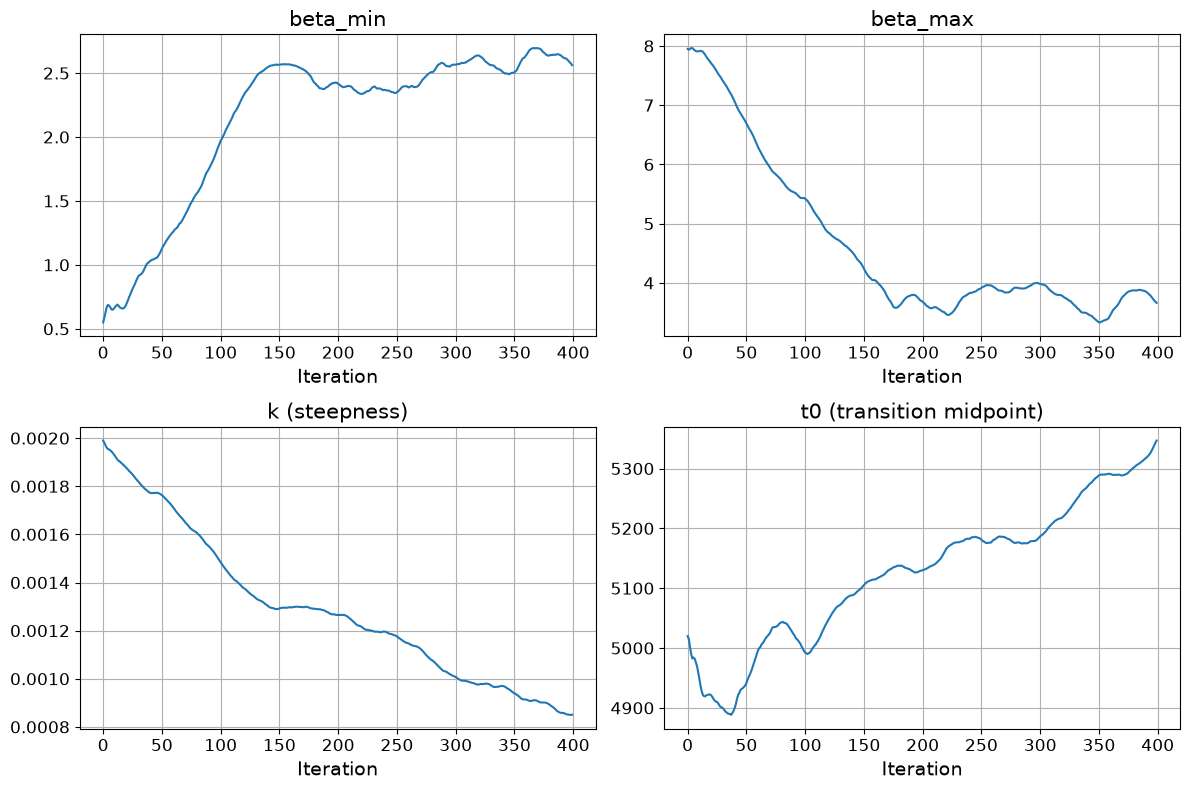

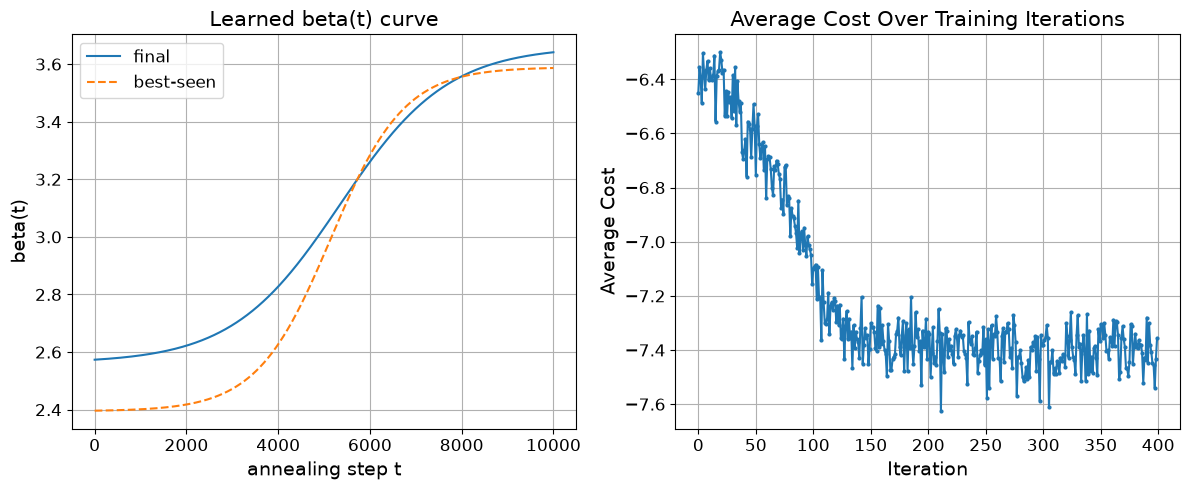

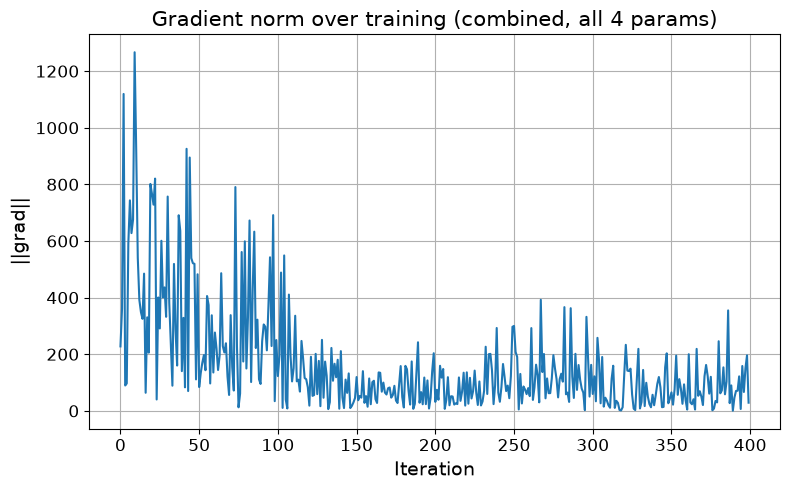

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(beta_min_history); axes[0,0].set_title("beta_min"); axes[0,0].grid(True)
axes[0,1].plot(beta_max_history); axes[0,1].set_title("beta_max"); axes[0,1].grid(True)
axes[1,0].plot(k_history); axes[1,0].set_title("k (steepness)"); axes[1,0].grid(True)
axes[1,1].plot(t0_history); axes[1,1].set_title("t0 (transition midpoint)"); axes[1,1].grid(True)
for ax in axes.flat:
    ax.set_xlabel("Iteration")
plt.tight_layout()
save_figure(fig, "sigmoid_param_evolution")
plt.show()

t_arr = np.arange(num_time_steps)
final_curve, _ = beta_of_t(t_arr, params[0], params[1], params[2], params[3])
best_curve, _ = beta_of_t(t_arr, best_params[0], best_params[1], best_params[2], best_params[3])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(final_curve, label="final")
axes[0].plot(best_curve, label="best-seen", linestyle="--")
axes[0].set_title("Learned beta(t) curve")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
save_figure(fig, "sigmoid_final_curve_and_cost")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grad_norm_history)
ax.set_title("Gradient norm over training (combined, all 4 params)")
ax.set_xlabel("Iteration")
ax.set_ylabel("||grad||")
ax.grid(True)
plt.tight_layout()
save_figure(fig, "sigmoid_grad_norm")
plt.show()


## Held-out evaluation

In [9]:
final_costs = evaluate_sigmoid(d0, Gamma, params[0], params[1], params[2], params[3],
                                num_time_steps, num_eval_experiments)
best_costs = evaluate_sigmoid(d0, Gamma, best_params[0], best_params[1], best_params[2], best_params[3],
                               num_time_steps, num_eval_experiments)

print(f"final schedule   (beta_min={params[0]:.3f}, beta_max={params[1]:.3f}, "
      f"k={params[2]:.5f}, t0={params[3]:.1f}):")
print(f"  mean={final_costs.mean():.3f} std={final_costs.std():.3f} success_prob={np.mean(final_costs==-9):.3f}")

print(f"best-seen schedule (beta_min={best_params[0]:.3f}, beta_max={best_params[1]:.3f}, "
      f"k={best_params[2]:.5f}, t0={best_params[3]:.1f}):")
print(f"  mean={best_costs.mean():.3f} std={best_costs.std():.3f} success_prob={np.mean(best_costs==-9):.3f}")


final schedule   (beta_min=2.562, beta_max=3.662, k=0.00085, t0=5346.8):
  mean=-7.412 std=1.072 success_prob=0.159
best-seen schedule (beta_min=2.395, beta_max=3.589, k=0.00124, t0=5141.0):
  mean=-7.418 std=1.097 success_prob=0.171


## Save results

In [10]:
t_arr = np.arange(num_time_steps)
final_curve, _ = beta_of_t(t_arr, params[0], params[1], params[2], params[3])
best_curve, _ = beta_of_t(t_arr, best_params[0], best_params[1], best_params[2], best_params[3])

with open(os.path.join(OUTPUT_DIR, "reinforce_sigmoid_schedule_cpu.pkl"), "wb") as f:
    pickle.dump({
        "beta_min": params[0], "beta_max": params[1], "k": params[2], "t0": params[3],
        "best_params": best_params,
        "best_cost_so_far": best_cost_so_far,
        "beta_schedule": final_curve,
        "best_beta_schedule": best_curve,
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "beta_min_history": beta_min_history, "beta_max_history": beta_max_history,
        "k_history": k_history, "t0_history": t0_history,
        "final_costs": final_costs, "best_costs": best_costs,
        "num_time_steps": num_time_steps,
    }, f)

param_df = pd.DataFrame([
    {"version": "final", "beta_min": params[0], "beta_max": params[1],
     "k": params[2], "t0": params[3], "cost": cost_history[-1]},
    {"version": "best_seen", "beta_min": best_params[0], "beta_max": best_params[1],
     "k": best_params[2], "t0": best_params[3], "cost": best_cost_so_far},
])
param_df.to_csv(os.path.join(OUTPUT_DIR, "sigmoid_params_cpu.csv"), index=False)

print("saved to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))


saved to: run_20260720_151538
['checkpoint.pkl', 'reinforce_sigmoid_schedule_cpu.pkl', 'sigmoid_final_curve_and_cost.png', 'sigmoid_final_curve_and_cost.svg', 'sigmoid_grad_norm.png', 'sigmoid_grad_norm.svg', 'sigmoid_params_cpu.csv', 'sigmoid_param_evolution.png', 'sigmoid_param_evolution.svg']


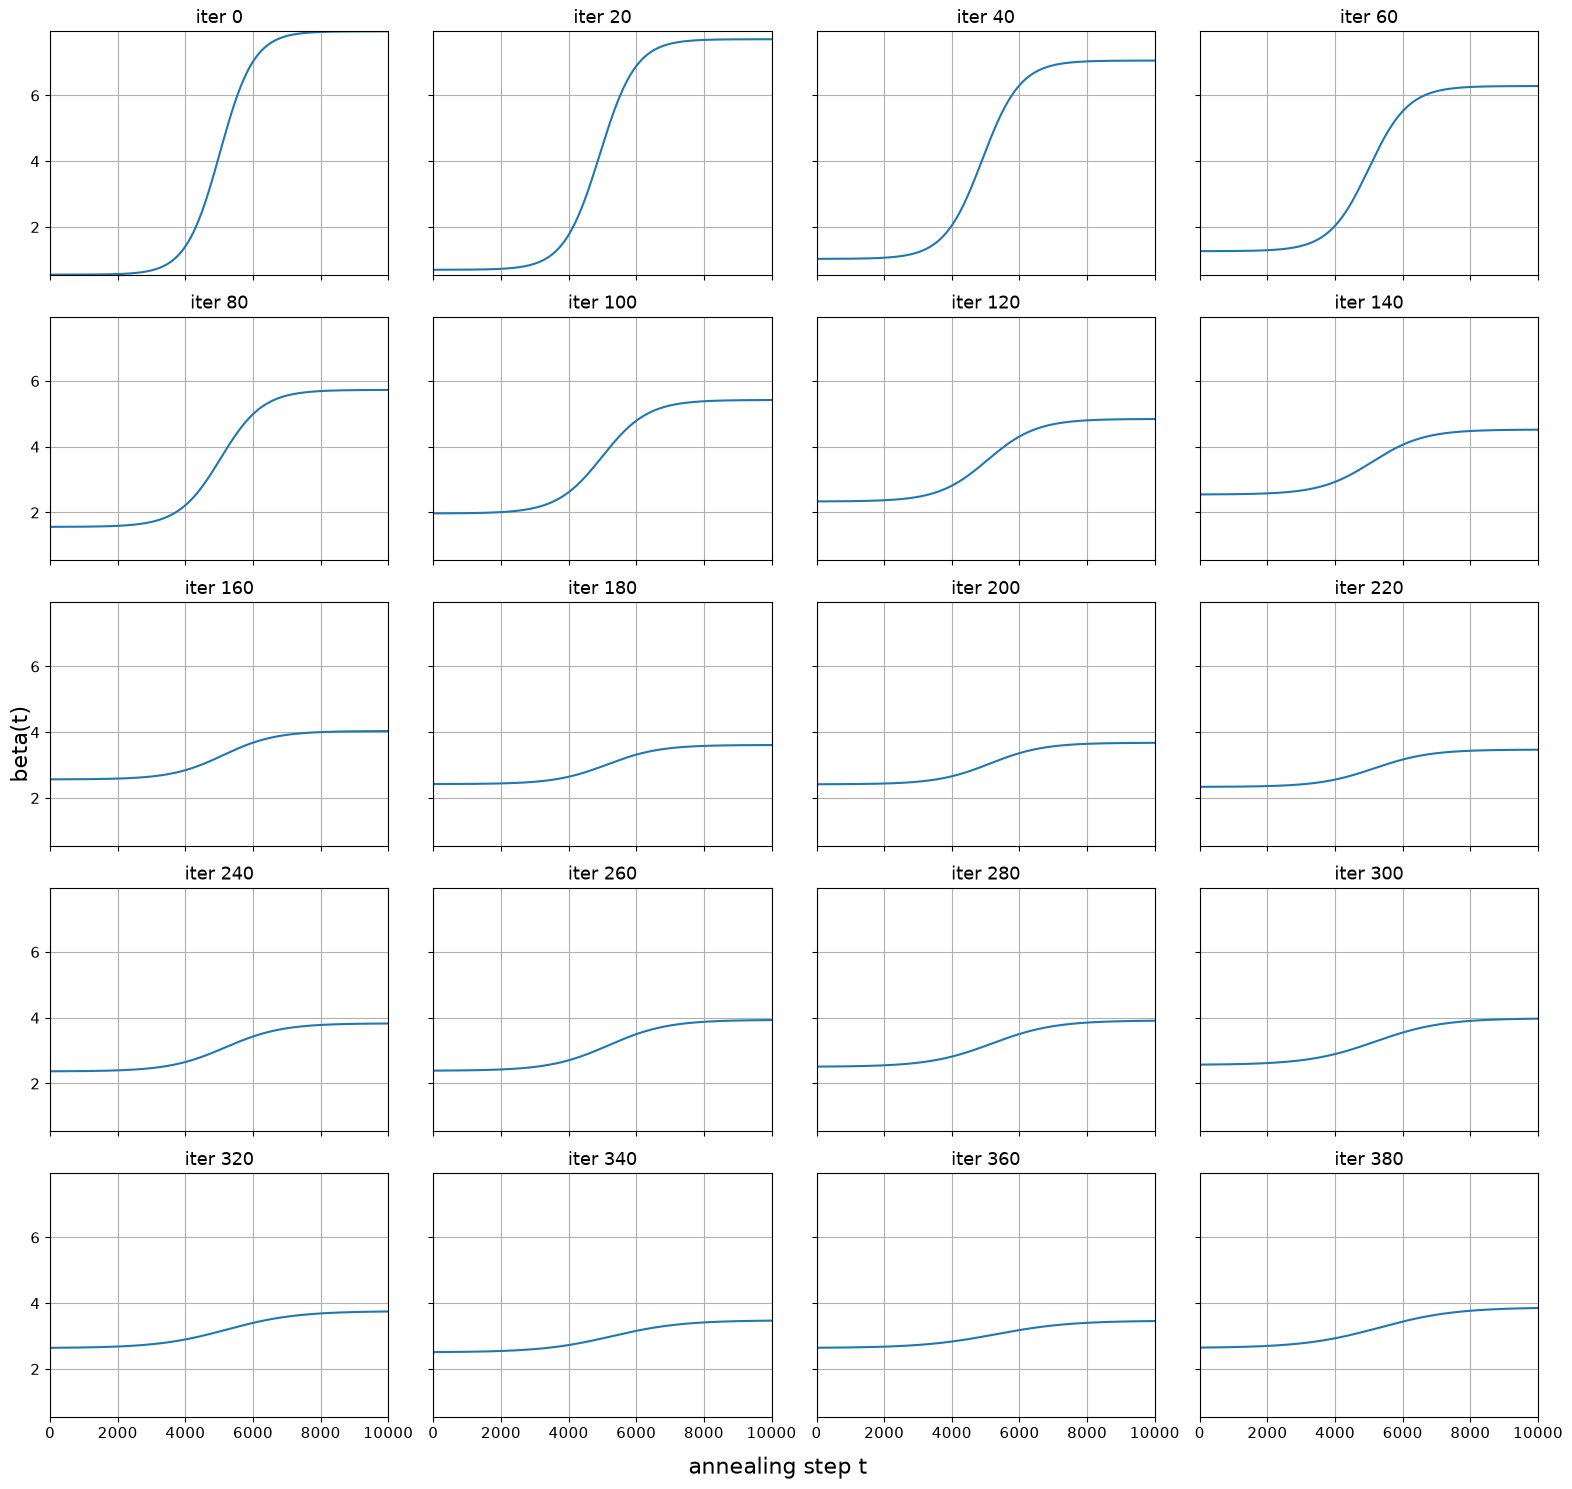

In [12]:
SNAPSHOT_INTERVAL = 20   # how many training iterations between each panel -- pick any value you like

snapshot_iters = list(range(0, len(beta_min_history), SNAPSHOT_INTERVAL))
t_arr = np.arange(num_time_steps)

curves = []
for it in snapshot_iters:
    curve, _ = beta_of_t(t_arr, beta_min_history[it], beta_max_history[it],
                          k_history[it], t0_history[it])
    curves.append(curve)

n_cols = 4
n_rows = int(np.ceil(len(curves) / n_cols))
y_min = min(c.min() for c in curves)
y_max = max(c.max() for c in curves)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, (it, curve) in enumerate(zip(snapshot_iters, curves)):
    axes[i].plot(curve)
    axes[i].set_title(f"iter {it}", fontsize=13)
    axes[i].set_xlim(0, num_time_steps)
    axes[i].set_ylim(y_min, y_max)
    axes[i].grid(True)
    axes[i].tick_params(labelsize=11)

for j in range(len(curves), len(axes)):
    axes[j].axis("off")

fig.supxlabel("annealing step t", fontsize=16)
fig.supylabel("beta(t)", fontsize=16)
plt.tight_layout()
save_figure(fig, "schedule_snapshots_grid")
plt.show()